# Session 1 — What Materials Informatics Is (and Isn't)

**Practical AI & Machine Learning for Materials Science · ACerS short course**

In this notebook you will:
1. Load a real materials dataset with `pandas` and look at it critically.
2. Turn chemical formulas into something a computer can count.
3. Find the *biases* hiding in a dataset before a model ever sees it.
4. Practice **problem framing**, which is where most ML projects succeed or fail.

> **Key takeaway:** most ML projects fail because the problem was badly formulated, not because the wrong algorithm was used.

**Optional pre-watch** (from the [course YouTube playlist](https://www.youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)):
- 📺 [2. What is Materials Informatics?](https://www.youtube.com/watch?v=65vCdOibwhQ&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)
- 📺 [3. How are materials discovered?](https://www.youtube.com/watch?v=RRNcqJSJ6vc&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)
- 📺 [4. Machine Learning vs Materials Informatics](https://www.youtube.com/watch?v=nDGDMKB0C6w&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)
- 📺 [7. Machine Learning Tasks and Types](https://www.youtube.com/watch?v=N_wFjy3ZWjg&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)

*Want more?* [5. Materials Data Repositories](https://www.youtube.com/watch?v=cdSENQPsAiI&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0) · [6. Materials Data Access (Materials Project API)](https://www.youtube.com/watch?v=Vuu7bNzmL8g&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)


## 0. Setup
Run the next cell first. In Google Colab it downloads the workshop repository. Locally it locates the repo folder.

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workshop_utils import load_dataset, parse_formula, element_fractions

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 110

## 1. Materials informatics in one picture

The core loop of the course is **build → measure → learn**:

```
  ┌──────────── data (experiments, DFT, literature) ────────────┐
  │                                                             ▼
decide what to  ◄── learn (model + uncertainty) ◄── represent (features)
make / measure next
```

**What materials informatics *is*:** using data and statistical models to make better and faster *decisions* about which materials to make, measure or simulate next.

**What it is *not*:**
- a replacement for physics, chemistry or domain expertise (those decide the features, the sanity checks and the decisions)
- a way to rescue a dataset that is too small, too biased or too noisy
- "accuracy on a test set", which is the start of the work, not the end

### High-value use cases in ceramics
| Use case | Typical input | Typical output | Why ML helps |
|---|---|---|---|
| Property screening | composition / structure | modulus, band gap, κ, Tm… | rank thousands of candidates before synthesis |
| Process optimization | sintering T, time, atmosphere, powder size | density, grain size, strength | fewer furnace runs (Bayesian optimization, Session 5) |
| Microstructure analysis | SEM / optical images | phase fractions, porosity, defects | automate tedious quantification |
| Literature mining | papers, reports | structured property tables | turn PDFs into datasets (LLMs, Session 6) |
| Inverse design | target property window | candidate compositions | search huge spaces efficiently |

## 2. Meet the dataset

We'll start with ~4,900 **bulk moduli** (GPa) from AFLOW's AEL-AGL DFT calculations. Each row is one composition.

In [3]:
df = load_dataset("bulk_modulus")
df.head()

,formula,target
0,Dy1Rh2,155.5060
1,Ba1Pt1,50.2714
2,B2Ru3Tb1,215.7170
3,Au2In1U1,79.7778
4,Ca3Co4Sn13,66.5500


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4905 entries, 0 to 4904
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   formula  4905 non-null   str    
 1   target   4905 non-null   float64
dtypes: float64(1), str(1)
memory usage: 76.8 KB


,target
count,4905.000000
mean,109.885496
std,68.138427
min,0.666667
25%,58.792700
50%,96.860100
75%,150.433000
max,434.908000


**Stop and think** before going further:
- These are *DFT* values, not experiments. What systematic differences might that introduce?
- Formulas look like `Dy1Rh2`. Is a formula enough to define a material? (Hint: think of polymorphs such as rutile and anatase TiO₂.)
- Are there duplicate formulas? Missing values? Negative moduli?

In [5]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate formulas:", df["formula"].duplicated().sum())
print("Non-physical (<= 0 GPa) moduli:", (df["target"] <= 0).sum())

Missing values:
 formula    0
target     0
dtype: int64

Duplicate formulas: 0
Non-physical (<= 0 GPa) moduli: 0


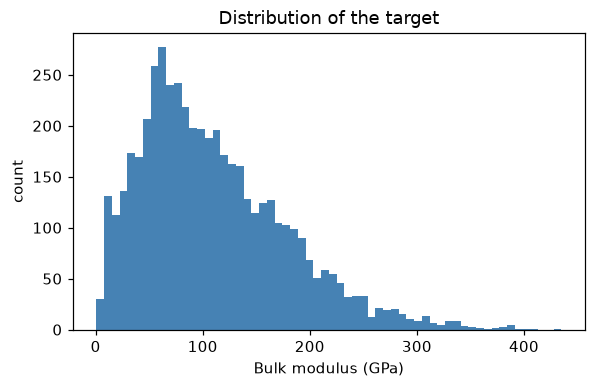

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df["target"], bins=60, color="steelblue")
ax.set_xlabel("Bulk modulus (GPa)")
ax.set_ylabel("count")
ax.set_title("Distribution of the target")
plt.show()

## 3. From formula to numbers

A model can't read `Al2O3`. The first step is always to **parse** it.

In [7]:
for f in ["Al2O3", "BaTiO3", "Ba0.5Sr0.5TiO3", "Ca10(PO4)6(OH)2", "Dy1Rh2"]:
    print(f"{f:18s} → {parse_formula(f)}")

Al2O3              → {'Al': 2.0, 'O': 3.0}
BaTiO3             → {'Ba': 1.0, 'Ti': 1.0, 'O': 3.0}
Ba0.5Sr0.5TiO3     → {'Ba': 0.5, 'Sr': 0.5, 'Ti': 1.0, 'O': 3.0}
Ca10(PO4)6(OH)2    → {'Ca': 10.0, 'P': 6.0, 'O': 26.0, 'H': 2.0}
Dy1Rh2             → {'Dy': 1.0, 'Rh': 2.0}


In [8]:
print(element_fractions("Al2O3"))

{'Al': 0.4, 'O': 0.6}


Let's add a few simple descriptive columns: number of elements and the anion "family".

In [9]:
df["n_elements"] = df["formula"].map(lambda f: len(parse_formula(f)))

def ceramic_family(formula):
    """Rough chemistry label from the most electronegative anion present."""
    els = parse_formula(formula)
    for anion, label in [("O", "oxide"), ("N", "nitride"), ("C", "carbide"),
                         ("B", "boride"), ("Si", "silicide"), ("S", "sulfide")]:
        if anion in els and len(els) > 1:
            return label
    return "other / intermetallic"

df["family"] = df["formula"].map(ceramic_family)
df["family"].value_counts()

family
other / intermetallic    3232
oxide                     491
silicide                  351
carbide                   229
sulfide                   215
nitride                   203
boride                    184
Name: count, dtype: int64

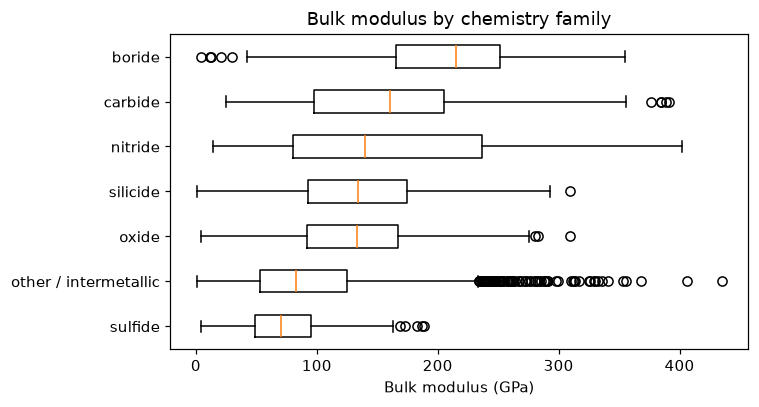

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.8))
order = df.groupby("family")["target"].median().sort_values().index
ax.boxplot([df.loc[df.family == f, "target"] for f in order], tick_labels=order,
           orientation="horizontal")
ax.set_xlabel("Bulk modulus (GPa)")
ax.set_title("Bulk modulus by chemistry family")
plt.tight_layout()
plt.show()

## 4. Look for bias *before* modeling

Which elements are actually in this dataset? A model can only learn about chemistry it has seen.

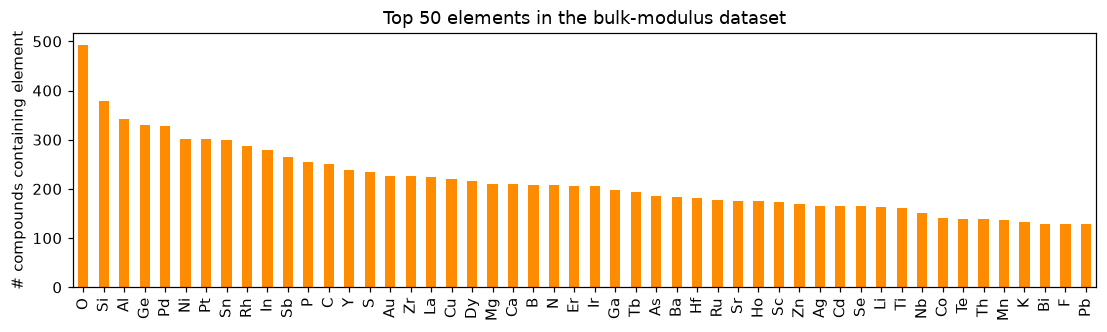

Number of distinct elements: 85
Least represented: {'Nd': 10, 'Eu': 8, 'Xe': 1, 'Ac': 1, 'Kr': 1, 'Sm': 1, 'He': 1, 'Ne': 1}


In [11]:
from collections import Counter

element_counts = Counter(el for f in df["formula"] for el in parse_formula(f))
counts = pd.Series(element_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 3))
counts.head(50).plot.bar(ax=ax, color="darkorange")
ax.set_ylabel("# compounds containing element")
ax.set_title("Top 50 elements in the bulk-modulus dataset")
plt.show()

print("Number of distinct elements:", len(counts))
print("Least represented:", counts.tail(8).to_dict())

**Discussion:**
- Oxides make up only ~10% of this set. A model trained on it may struggle on *your* oxide ceramics. (We test this directly in Session 4.)
- Look at the most common elements. Were they chosen because they matter for applications, or because they were convenient to compute?
- Count the compounds with 4+ elements in the next cell. Most real ceramics (doped oxides, solid solutions, high-entropy ceramics) are multicomponent. What does that imply?

In [12]:
df["n_elements"].value_counts().sort_index()

n_elements
1      52
2    2034
3    2819
Name: count, dtype: int64

## 5. What is "one sample"? A second dataset

Heat capacity depends on temperature, so the same formula appears many times.

In [13]:
cp = load_dataset("heat_capacity_clean")
print(cp.shape, "rows,", cp["formula"].nunique(), "unique formulas")
cp.head(8)

(4547, 3) rows, 244 unique formulas


,formula,T,Cp
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625
5,B2O3,900.0,116.190
6,B2O3,800.0,111.169
7,B2O3,723.0,106.692


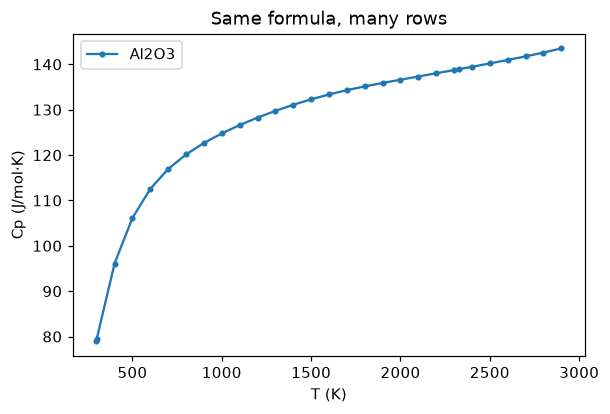

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.8))
for f in ["Al2O3", "MgO", "SiO2", "ZrO2", "TiO2"]:
    sub = cp[cp.formula == f].sort_values("T")
    if len(sub):
        ax.plot(sub["T"], sub["Cp"], marker=".", label=f)
ax.set_xlabel("T (K)"); ax.set_ylabel("Cp (J/mol·K)")
ax.legend(); ax.set_title("Same formula, many rows")
plt.show()

If you randomly split these rows into train and test sets, Al₂O₃ at 1000 K ends up in training and Al₂O₃ at 1100 K in testing. The model has effectively already seen the answer.
This is **data leakage**, and it is one of the most common ways materials-ML papers fool themselves. We'll measure how much it matters in Session 3.

## 6. Your turn: frame an ML-ready problem from your own work

Fill in the worksheet below (or `problem_framing_worksheet.md` in this folder). Be specific.

| Question | Your answer |
|---|---|
| **Decision** this model will inform (what will you do differently?) | |
| **Output** (property / label) and units | |
| **Inputs** you will *actually have* at prediction time | |
| **How many** labeled examples exist today? From where? | |
| **How noisy** are the labels (repeat-measurement scatter)? | |
| **Baseline**: what does an expert or a simple rule achieve? | |
| **Success metric** and the error that would still be useful | |
| **Extrapolation?** Will you predict outside the chemistry/process range in your data? | |

**Red flags:** fewer than ~50 data points with no physics-based features; inputs that won't be known at decision time; a target defined differently across labs; "we want to predict everything".

### Optional exercises
1. Which family has the **widest** spread of bulk modulus? Why might that be?
2. Load `load_dataset("bandgap")`. What fraction of entries have a band gap of exactly 0? What does that mean for modeling?
3. Look at the 10 stiffest compounds (next cell). Do they make physical sense?

In [15]:
# Exercise space: the 10 stiffest compounds
df.sort_values("target", ascending=False).head(10)

,formula,target,n_elements,family
88,C1,434.908,1,other / intermetallic
1792,Os1,406.445,1,other / intermetallic
1680,C11N4,401.737,2,nitride
217,C1N2,398.685,2,nitride
1003,C1Re2,391.213,2,carbide
839,C1Re1,388.950,2,carbide
1481,C3N4,388.650,2,nitride
3524,B1C7,385.055,2,carbide
4226,C1Os1,384.283,2,carbide
1301,N1Re2,381.325,2,nitride


---
**Next session:** turning formulas into *feature vectors* (composition-based feature vectors, CBFV).

**Go deeper:** the full University of Utah course repo, [sp8rks/MaterialsInformatics](https://github.com/sp8rks/MaterialsInformatics): `worked_examples/MP_API_example` (Materials Project API), `worked_examples/data_wrangling`, `worked_examples/ydata_profiling`.